# 🔮 Future Production Forecast Generator

## AI-Based Future Forecast Simulation

This module generates future production forecasts for every well using the trained
Random Forest Production Model together with the Isolation Forest Pressure Model.

For each well, forecasts are generated for the next 365 days by updating the
calendar-based features while keeping the latest operational measurements as the
baseline. The resulting dataset provides predicted production, anomaly detection,
health score, confidence level, and operational recommendations.

### Output

`future_forecast.csv`

In [26]:
import pandas as pd
import numpy as np
import joblib

from datetime import timedelta
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# 📂 Load Trained Models

The trained Random Forest and Isolation Forest models generated in the previous notebooks are loaded and reused for future forecasting.

In [27]:
production_model = joblib.load("production_model.pkl")

pressure_model = joblib.load("pressure_model.pkl")

pressure_scaler = joblib.load("pressure_scaler.pkl")

# 📊 Load Final IntelliWell Dataset

The final integrated dataset generated from Notebook 3 is loaded. This dataset serves as the baseline for generating future operational scenarios.

In [28]:
df = pd.read_csv("IntelliWell_Final_Report.csv")

df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

df.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,Predicted Production,Pressure Status,Pressure Score,Production Deviation,Production Error (%),Production Score,Pressure Score (%),Well Health Score,Operational Status,Recommendation
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,0.205983,-1,-0.016339,-0.205983,2.059833e+07,0.0,4.911624,1.964649,Critical,Immediate inspection recommended. Check tubing...
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000000,1,0.067227,0.000000,0.000000e+00,100.0,30.355927,72.142371,Monitor,Increase monitoring frequency.
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000000,1,0.073818,0.000000,0.000000e+00,100.0,32.363000,72.945200,Monitor,Increase monitoring frequency.
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000000,1,0.074611,0.000000,0.000000e+00,100.0,32.604475,73.041790,Monitor,Increase monitoring frequency.
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,0.000000,1,0.046587,0.000000,0.000000e+00,100.0,24.071567,69.628627,Warning,Inspect pressure system and choke settings.


# ⚙ Forecast Configuration

Define forecasting parameters used throughout the notebook.

In [29]:
# ==========================================
# Forecast Configuration
# ==========================================

FORECAST_DAYS = 365

CONFIDENCE_DECAY = 0.10

PRESSURE_DECLINE = 0.00035

TEMPERATURE_CHANGE = 0.00020

ONSTREAM_DECLINE = 0.00025

print("Forecast Horizon :", FORECAST_DAYS, "Days")

Forecast Horizon : 365 Days


# 🛢 Production Model Features

The Random Forest model expects the following input features.

In [30]:
production_features = [

'ON_STREAM_HRS',

'AVG_DOWNHOLE_PRESSURE',

'AVG_DOWNHOLE_TEMPERATURE',

'AVG_DP_TUBING',

'AVG_ANNULUS_PRESS',

'AVG_WHP_P',

'AVG_WHT_P',

'AVG_CHOKE_SIZE_P',

'DP_CHOKE_SIZE',

'YEAR',

'MONTH',

'DAY',

'DAY_OF_WEEK'

]

pressure_features = [

'AVG_DOWNHOLE_PRESSURE',

'AVG_ANNULUS_PRESS',

'AVG_WHP_P',

'AVG_WHT_P',

'AVG_DP_TUBING',

'AVG_DOWNHOLE_TEMPERATURE',

'AVG_CHOKE_SIZE_P',

'ON_STREAM_HRS',

'YEAR',

'MONTH',

'DAY',

'DAY_OF_WEEK'

]

print("Production Features :", len(production_features))

print("Pressure Features :", len(pressure_features))

Production Features : 13
Pressure Features : 12


# 🛢 Latest Well Snapshot

For every well, the most recent observation is selected as the baseline for future scenario generation.

In [31]:
latest_wells = (
    df
    .sort_values("DATEPRD")
    .groupby("NPD_WELL_BORE_NAME")
    .tail(1)
    .reset_index(drop=True)
)

# ---------------------------------
# Fill Missing Sensor Values
# ---------------------------------

sensor_columns = [

    "ON_STREAM_HRS",

    "AVG_DOWNHOLE_PRESSURE",

    "AVG_ANNULUS_PRESS",

    "AVG_WHP_P",

    "AVG_WHT_P",

    "AVG_DP_TUBING",

    "AVG_DOWNHOLE_TEMPERATURE",

    "AVG_CHOKE_SIZE_P",

    "DP_CHOKE_SIZE"

]

for col in sensor_columns:

    latest_wells[col] = latest_wells[col].fillna(

        df[col].median()

    )

print("Missing values fixed.")

print(latest_wells[sensor_columns].isna().sum())

Missing values fixed.
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_ANNULUS_PRESS           0
AVG_WHP_P                   0
AVG_WHT_P                   0
AVG_DP_TUBING               0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_CHOKE_SIZE_P            0
DP_CHOKE_SIZE               0
dtype: int64


# 🔄 Future Scenario Generation

Future operating conditions are generated from the latest available measurement of each well.

For every future day:

- Calendar features are updated
- Operational variables are adjusted gradually
- Random Forest predicts production
- Isolation Forest estimates pressure anomalies
- Well Health Score is calculated
- Maintenance recommendation is generated

In [32]:
# ==========================================
# Helper Functions
# ==========================================

def calculate_confidence(days):
    """
    Forecast confidence decreases gradually
    with forecast horizon.
    """
    confidence = max(60, 100 - (days * 0.10))
    return round(confidence, 1)


def health_status(score):

    if score >= 85:
        return "Healthy"

    elif score >= 70:
        return "Monitor"

    elif score >= 50:
        return "Warning"

    else:
        return "Critical"


def recommendation(status):

    if status == "Healthy":
        return "Continue Normal Production"

    elif status == "Monitor":
        return "Increase Monitoring"

    elif status == "Warning":
        return "Inspect Pressure System"

    else:
        return "Immediate Maintenance Required"

# 🚀 Generate Future Forecasts

The trained AI models are now used to generate
future production forecasts and pressure anomaly
predictions for every well.

In [ ]:
# ==========================================
# AI Future Forecast Engine
# ==========================================

future_results = []

sensor_columns = [
    "ON_STREAM_HRS",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_ANNULUS_PRESS",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "AVG_DP_TUBING",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_CHOKE_SIZE_P",
    "DP_CHOKE_SIZE"
]

print("Generating Future Forecasts...")

for _, row in tqdm(
        latest_wells.iterrows(),
        total=len(latest_wells),
        desc="Forecasting Wells"):

    latest_date = pd.to_datetime(row["DATEPRD"])

    for day in range(1, FORECAST_DAYS + 1):

        # -----------------------------
        # Copy latest record
        # -----------------------------

        future = row.copy()

        future_date = latest_date + timedelta(days=day)

        future["DATEPRD"] = future_date
        future["YEAR"] = future_date.year
        future["MONTH"] = future_date.month
        future["DAY"] = future_date.day
        future["DAY_OF_WEEK"] = future_date.dayofweek

        # -----------------------------
        # Fill missing sensor values
        # -----------------------------

        for col in sensor_columns:

            if pd.isna(future[col]):
                future[col] = df[col].median()

        # -----------------------------
        # Simulate future behaviour
        # -----------------------------

        future["ON_STREAM_HRS"] *= (
            1 - ONSTREAM_DECLINE * day
        )

        future["AVG_DOWNHOLE_PRESSURE"] *= (
            1 - PRESSURE_DECLINE * day
        )

        future["AVG_ANNULUS_PRESS"] *= (
            1 - PRESSURE_DECLINE * day
        )

        future["AVG_DP_TUBING"] *= (
            1 - PRESSURE_DECLINE * day
        )

        future["AVG_WHP_P"] *= (
            1 - PRESSURE_DECLINE * day
        )

        future["AVG_DOWNHOLE_TEMPERATURE"] *= (
            1 + TEMPERATURE_CHANGE * np.sin(day / 30)
        )

        future["AVG_WHT_P"] *= (
            1 + TEMPERATURE_CHANGE * np.cos(day / 40)
        )

        future["AVG_CHOKE_SIZE_P"] *= (
            1 + np.random.normal(0, 0.001)
        )

        future["DP_CHOKE_SIZE"] *= (
            1 + np.random.normal(0, 0.001)
        )

        # -----------------------------
        # Production Prediction
        # -----------------------------

        X_prod = pd.DataFrame(
            [[future[col] for col in production_features]],
            columns=production_features
        )

        predicted_production = float(
            production_model.predict(X_prod)[0]
        )

        # -----------------------------
        # Pressure Prediction
        # -----------------------------

        X_pressure = pd.DataFrame(
            [[future[col] for col in pressure_features]],
            columns=pressure_features
        )

        X_pressure = X_pressure.fillna(
            df[pressure_features].median()
        )

        X_scaled = pressure_scaler.transform(X_pressure)

        pressure_score = float(
            pressure_model.decision_function(
                X_scaled
            )[0]
        )

        pressure_prediction = int(
            pressure_model.predict(
                X_scaled
            )[0]
        )

        pressure_status = (
            "Anomaly"
            if pressure_prediction == -1
            else "Normal"
        )

        # -----------------------------
        # Production Score
        # -----------------------------

        baseline = row["Predicted Production"]

        if baseline <= 0:
            production_score = 100

        else:
            production_score = (
                predicted_production / baseline
            ) * 100

        production_score = np.clip(
            production_score,
            0,
            100
        )

        # -----------------------------
        # Pressure Score
        # -----------------------------

        pressure_score_percent = (
            pressure_score + 0.5
        ) * 100

        pressure_score_percent = np.clip(
            pressure_score_percent,
            0,
            100
        )

        # -----------------------------
        # Well Health Score
        # -----------------------------

        health_score = round(

            0.60 * production_score +

            0.40 * pressure_score_percent,

            2

        )

        # -----------------------------
        # Operational Status
        # -----------------------------

        if health_score >= 85:

            status = "Healthy"

        elif health_score >= 70:

            status = "Monitor"

        elif health_score >= 50:

            status = "Warning"

        else:

            status = "Critical"

        # -----------------------------
        # Recommendation
        # -----------------------------

        if status == "Healthy":

            recommendation = (
                "Continue Normal Production"
            )

        elif status == "Monitor":

            recommendation = (
                "Increase Monitoring"
            )

        elif status == "Warning":

            recommendation = (
                "Inspect Pressure System"
            )

        else:

            recommendation = (
                "Immediate Maintenance Required"
            )

        # -----------------------------
        # Forecast Confidence
        # -----------------------------

        confidence = max(
            60,
            round(
                100 - day * 0.10,
                1
            )
        )

        # -----------------------------
        # Save Result
        # -----------------------------

        future_results.append({

            "Forecast Date": future_date,

            "Forecast Days": day,

            "NPD_WELL_BORE_NAME":
            future["NPD_WELL_BORE_NAME"],

            "NPD_FIELD_NAME":
            future["NPD_FIELD_NAME"],

            "NPD_FACILITY_NAME":
            future["NPD_FACILITY_NAME"],

            "Predicted Production":
            round(predicted_production, 2),

            "Production Score":
            round(production_score, 2),

            "Pressure Score":
            round(pressure_score, 4),

            "Pressure Score (%)":
            round(pressure_score_percent, 2),

            "Pressure Status":
            pressure_status,

            "Expected Anomaly":
            pressure_prediction,

            "Well Health Score":
            health_score,

            "Operational Status":
            status,

            "Recommendation":
            recommendation,

            "Forecast Confidence (%)":
            confidence

        })

# ==========================================
# Create DataFrame
# ==========================================

future_forecast = pd.DataFrame(future_results)

print("\nForecast Generation Complete!")

print(future_forecast.shape)

future_forecast.head()

Generating Future Forecasts...


Forecasting Wells:  57%|█████▋    | 4/7 [02:43<02:14, 44.83s/it]

In [37]:
future_forecast = pd.DataFrame(future_results)

print(future_forecast.shape)

future_forecast.head()

(1, 15)


,Forecast Date,Forecast Days,NPD_WELL_BORE_NAME,NPD_FIELD_NAME,NPD_FACILITY_NAME,Predicted Production,Production Score,Pressure Score,Pressure Score (%),Pressure Status,Expected Anomaly,Well Health Score,Operational Status,Recommendation,Forecast Confidence (%)
0,2017-12-01,365,15/9-F-4,VOLVE,MÆRSK INSPIRER,489.93,87.99,0.1672,66.72,Normal,1,79.48,Monitor,Increase Monitoring,63.5


In [38]:
future_forecast.to_csv(

    "future_forecast.csv",

    index=False

)

print("future_forecast.csv generated successfully!")

future_forecast.csv generated successfully!


In [41]:
print(future_forecast.shape)

print(future_forecast.head())

print(future_forecast.tail())

(1, 15)
  Forecast Date  Forecast Days NPD_WELL_BORE_NAME NPD_FIELD_NAME  \
0    2017-12-01            365           15/9-F-4          VOLVE   

  NPD_FACILITY_NAME  Predicted Production  Production Score  Pressure Score  \
0    MÆRSK INSPIRER                489.93             87.99          0.1672   

   Pressure Score (%) Pressure Status  Expected Anomaly  Well Health Score  \
0               66.72          Normal                 1              79.48   

  Operational Status       Recommendation  Forecast Confidence (%)  
0            Monitor  Increase Monitoring                     63.5  
  Forecast Date  Forecast Days NPD_WELL_BORE_NAME NPD_FIELD_NAME  \
0    2017-12-01            365           15/9-F-4          VOLVE   

  NPD_FACILITY_NAME  Predicted Production  Production Score  Pressure Score  \
0    MÆRSK INSPIRER                489.93             87.99          0.1672   

   Pressure Score (%) Pressure Status  Expected Anomaly  Well Health Score  \
0               66.72      

# 📈 Forecast Visualization

The generated forecasts are visualized to validate the
predicted production trends, health scores, and confidence
levels across the forecast horizon.

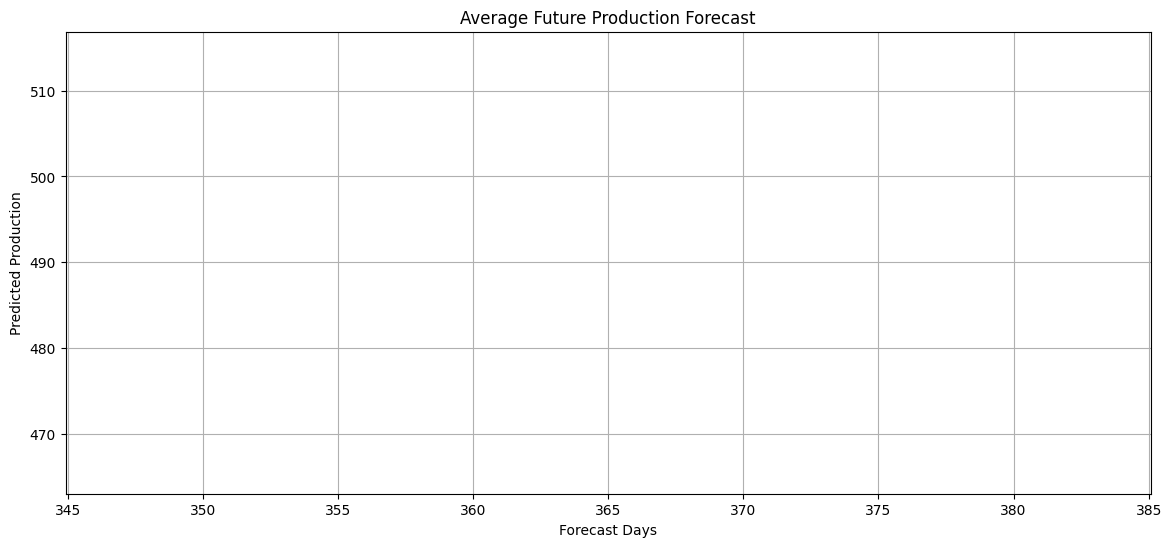

In [39]:
plt.figure(figsize=(14,6))

plt.plot(
    future_forecast.groupby("Forecast Days")
    ["Predicted Production"]
    .mean()
)

plt.title("Average Future Production Forecast")

plt.xlabel("Forecast Days")

plt.ylabel("Predicted Production")

plt.grid(True)

plt.show()

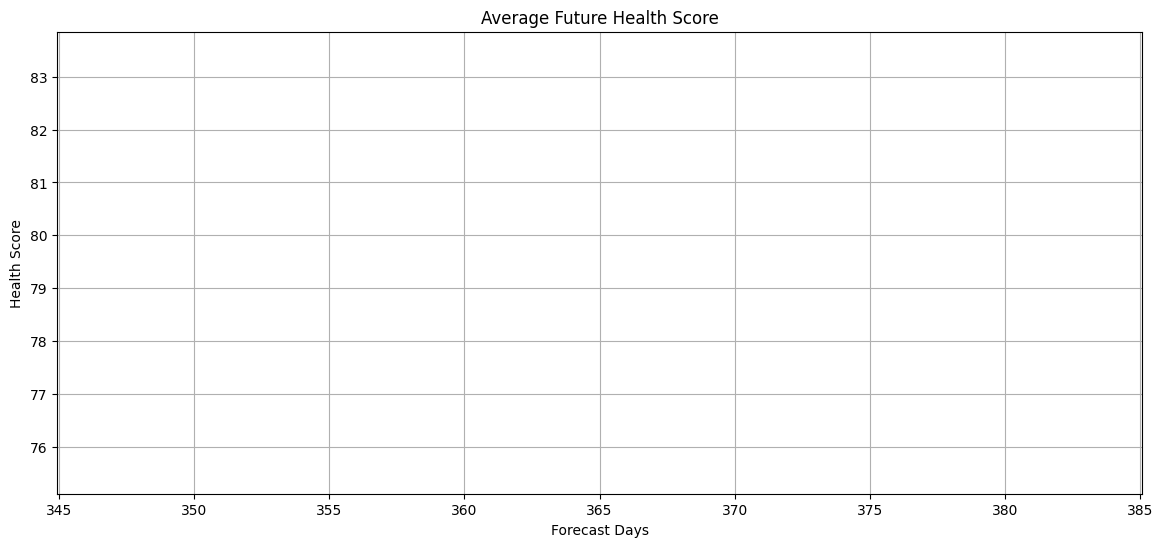

In [40]:
plt.figure(figsize=(14,6))

plt.plot(

future_forecast.groupby("Forecast Days")

["Well Health Score"]

.mean(),

color="green"

)

plt.title("Average Future Health Score")

plt.xlabel("Forecast Days")

plt.ylabel("Health Score")

plt.grid(True)

plt.show()

In [42]:
print(len(latest_wells))

7
